In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pa-100k/PA-100K/val.csv
/kaggle/input/pa-100k/PA-100K/README.txt
/kaggle/input/pa-100k/PA-100K/annotation.mat
/kaggle/input/pa-100k/PA-100K/train.csv
/kaggle/input/pa-100k/PA-100K/test.csv


In [ ]:
!pip install 

>>> Device: cuda | AMP: True | Image: 112x112
>>> Loading Annotations...


Caching Val: 100%|██████████| 10000/10000 [00:22<00:00, 445.30it/s]



[Stage 1] Warmup Head (5 epochs)...


Ep 1 | T_Loss: 0.1338 | V_Loss: 0.1436 | mA: 0.5812


Ep 2 | T_Loss: 0.1249 | V_Loss: 0.1430 | mA: 0.5810


...

Ep 26 | T_Loss: 0.0384 | V_Loss: 0.1231 | mA: 0.7166


Ep 27 | T_Loss: 0.0374 | V_Loss: 0.1209 | mA: 0.7220
   >>> ⭐️ Best Model Saved (mA: 0.7220)


Ep 28 | T_Loss: 0.0364 | V_Loss: 0.1271 | mA: 0.7160


Ep 29 | T_Loss: 0.0356 | V_Loss: 0.1273 | mA: 0.7162


Ep 30 | T_Loss: 0.0347 | V_Loss: 0.1305 | mA: 0.7165


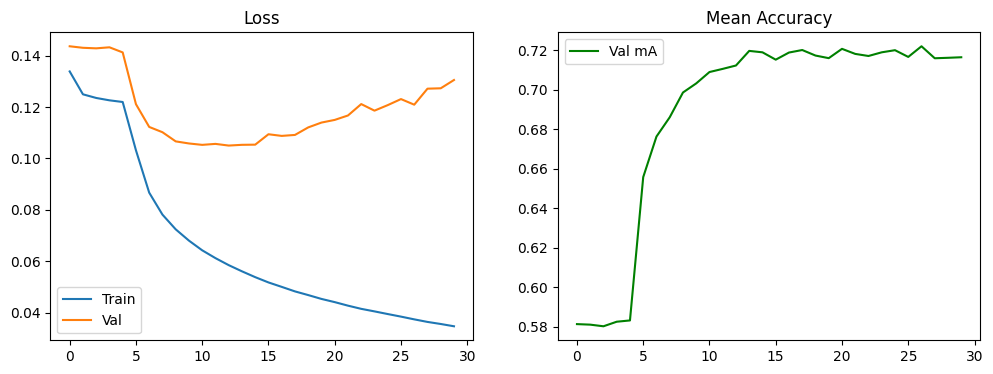

In [2]:
import os
import io
import warnings
import numpy as np
import scipy.io
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms as T
from PIL import Image
from tqdm import tqdm
import timm
import matplotlib.pyplot as plt
from IPython.display import clear_output

# --- 0. 屏蔽警告 ---
warnings.filterwarnings("ignore")

# --- 1. 配置与环境 ---
if os.path.exists('/kaggle/input'):
    ROOT_PATH = '/kaggle/input/pa-100k/PA-100K/data'
    MAT_PATH = '/kaggle/input/pa-100k/PA-100K/annotation.mat'
    NUM_WORKERS = 4 
else:
    ROOT_PATH = 'C:\\Users\\hsx\\Desktop\\pa100k\\PA-100K\\data'
    MAT_PATH = 'C:\\Users\\hsx\\Desktop\\pa100k\\PA-100K\\annotation.mat'
    NUM_WORKERS = 0 

CONFIG = {
    'root_path': ROOT_PATH,
    'mat_path': MAT_PATH,
    'model_name': 'mobilenetv4_conv_small_050.e3000_r224_in1k', 
    'img_size': 112,       
    'batch_size': 128,     
    'num_classes': 26,
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    'num_workers': NUM_WORKERS,
    'use_amp': True,       
    'warmup_epochs': 5,
    'finetune_epochs': 25,
    'warmup_lr': 1e-3,
    'finetune_lr': 5e-4
}

print(f">>> Device: {CONFIG['device']} | AMP: {CONFIG['use_amp']} | Image: {CONFIG['img_size']}x{CONFIG['img_size']}")

# --- 2. 数据准备 (内存缓存模式) ---
print(">>> Loading Annotations...")
try:
    mat = scipy.io.loadmat(CONFIG['mat_path'])
except FileNotFoundError:
    raise FileNotFoundError(f"标注文件未找到: {CONFIG['mat_path']}")

train_labels = mat['train_label'].astype(np.float32)
val_labels = mat['val_label'].astype(np.float32)
test_labels = mat['test_label'].astype(np.float32)

train_images = [img[0][0] for img in mat['train_images_name']]
val_images = [img[0][0] for img in mat['val_images_name']]
test_images = [img[0][0] for img in mat['test_images_name']]

# 计算权重
pos_counts = np.sum(train_labels, axis=0)
ratio = pos_counts / len(train_labels)
pos_weights = torch.tensor(np.exp(1 - ratio), dtype=torch.float32).to(CONFIG['device'])

class PA100KDataset(Dataset):
    def __init__(self, root_dir, image_names, labels, transform=None, cache_ram=False, desc="Loading"):
        self.root_dir = root_dir
        self.image_names = image_names
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.transform = transform
        self.cache_ram = cache_ram
        self.img_cache = {} 

        if self.cache_ram:
            # 这里的 tqdm 会显示缓存进度
            for i, name in enumerate(tqdm(image_names, desc=f"Caching {desc}")):
                path = os.path.join(root_dir, name)
                try:
                    with open(path, 'rb') as f:
                        self.img_cache[i] = f.read() 
                except:
                    pass

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        try:
            if self.cache_ram and idx in self.img_cache:
                img_bytes = self.img_cache[idx]
                img = Image.open(io.BytesIO(img_bytes)).convert('RGB')
            else:
                img_name = self.image_names[idx]
                img_path = os.path.join(self.root_dir, img_name)
                img = Image.open(img_path).convert('RGB')
        except:
            img = Image.new('RGB', (CONFIG['img_size'], CONFIG['img_size']), (0, 0, 0))

        if self.transform:
            img = self.transform(img)
            
        return img, self.labels[idx]

class CustomCutout:
    def __call__(self, img):
        if torch.rand(1) > 0.5:
            _, h, w = img.shape
            y, x = torch.randint(0, h, (1,)), torch.randint(0, w, (1,))
            h_e, w_e = int(h*0.15), int(w*0.15)
            y2 = min(h, y + h_e)
            x2 = min(w, x + w_e)
            img[:, y:y2, x:x2] = 0.0
        return img

normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_transform = T.Compose([
    T.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    CustomCutout(),
    normalize
])

val_transform = T.Compose([
    T.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    T.ToTensor(),
    normalize
])

# 创建 Dataset
train_dataset = PA100KDataset(CONFIG['root_path'], train_images, train_labels, 
                              transform=train_transform, cache_ram=True, desc="Train")
val_dataset = PA100KDataset(CONFIG['root_path'], val_images, val_labels, 
                            transform=val_transform, cache_ram=True, desc="Val")

# DataLoader 设置
use_persistent = (CONFIG['num_workers'] > 0)
prefetch = 4 if (CONFIG['num_workers'] > 0) else None

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'], 
    shuffle=True, 
    num_workers=CONFIG['num_workers'], 
    pin_memory=True,            
    persistent_workers=use_persistent,  
    prefetch_factor=prefetch,   
    drop_last=True              
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'], 
    shuffle=False, 
    num_workers=CONFIG['num_workers'], 
    pin_memory=True,
    persistent_workers=use_persistent,
    prefetch_factor=prefetch
)

# --- 3. 模型定义 ---
class PedestrianAttributeNet(nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=True, num_classes=0, global_pool='')
        
        with torch.no_grad():
            dummy = torch.randn(1, 3, CONFIG['img_size'], CONFIG['img_size'])
            out = self.backbone(dummy)
            self.in_features = out.shape[1]
            
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.BatchNorm1d(self.in_features),
            nn.Dropout(0.2),
            nn.Linear(self.in_features, num_classes)
        )
        
        nn.init.normal_(self.head[4].weight, 0, 0.01)
        nn.init.constant_(self.head[4].bias, 0)

    def forward(self, x):
        x = self.backbone(x)
        return self.head(x)

# --- 4. 辅助函数 ---
class WeightedFocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        loss = (1 - pt).pow(self.gamma) * bce_loss
        if self.alpha is not None:
            weights = targets * self.alpha + (1 - targets)
            loss = loss * weights
        return loss.mean()

def calculate_metrics(logits, targets):
    probs = torch.sigmoid(logits).numpy()
    targets = targets.numpy()
    preds = (probs > 0.5).astype(int)
    
    ma_list = []
    for i in range(targets.shape[1]):
        p_mask, n_mask = (targets[:, i] == 1), (targets[:, i] == 0)
        tp = np.sum(preds[p_mask, i] == 1)
        tn = np.sum(preds[n_mask, i] == 0)
        p_count, n_count = np.sum(p_mask), np.sum(n_mask)
        sens = tp / p_count if p_count > 0 else 0.5
        spec = tn / n_count if n_count > 0 else 0.5
        ma_list.append((sens + spec) / 2)
    
    tp_all = np.sum((preds == 1) & (targets == 1))
    fp_all = np.sum((preds == 1) & (targets == 0))
    fn_all = np.sum((preds == 0) & (targets == 1))
    prec = tp_all / (tp_all + fp_all + 1e-6)
    rec = tp_all / (tp_all + fn_all + 1e-6)
    f1 = 2 * prec * rec / (prec + rec + 1e-6)
    
    return np.mean(ma_list), f1

# --- 5. 训练循环 ---
def run_one_epoch(model, loader, criterion, optimizer=None, scaler=None, is_train=True):
    if is_train: model.train()
    else: model.eval()
    
    total_loss = 0
    all_logits, all_targets = [], []
    
    pbar = tqdm(loader, leave=False, desc="Train" if is_train else "Val")
    
    for images, labels in pbar:
        images, labels = images.to(CONFIG['device']), labels.to(CONFIG['device'])
        
        with torch.amp.autocast('cuda', enabled=CONFIG['use_amp']):
            outputs = model(images)
            loss = criterion(outputs, labels)
            
        if is_train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            all_logits.append(outputs.detach().cpu())
            all_targets.append(labels.detach().cpu())
            
        total_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        
    avg_loss = total_loss / len(loader)
    
    metrics = {'mA': 0.0, 'f1': 0.0}
    if not is_train and len(all_logits) > 0:
        logits_cat = torch.cat(all_logits)
        targets_cat = torch.cat(all_targets)
        mA, f1 = calculate_metrics(logits_cat, targets_cat)
        metrics = {'mA': mA, 'f1': f1}
        
    return avg_loss, metrics

# --- 6. 主程序 ---
def main():
    model = PedestrianAttributeNet(CONFIG['model_name'], CONFIG['num_classes']).to(CONFIG['device'])
    
    # 【已修改】检测到P100显卡，不支持torch.compile，已强制删除相关代码
    # 保持普通模式运行
    
    criterion = WeightedFocalLoss(alpha=pos_weights, gamma=2.0)
    scaler = torch.amp.GradScaler('cuda', enabled=CONFIG['use_amp'])
    
    history = {'train_loss': [], 'val_loss': [], 'mA': []}
    best_mA = 0.0
    
    # === Stage 1: Warmup ===
    print(f"\n[Stage 1] Warmup Head ({CONFIG['warmup_epochs']} epochs)...")
    
    for param in model.backbone.parameters(): param.requires_grad = False
    for param in model.head.parameters(): param.requires_grad = True
    
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                            lr=CONFIG['warmup_lr'], weight_decay=1e-2)
    
    for epoch in range(CONFIG['warmup_epochs']):
        t_loss, _ = run_one_epoch(model, train_loader, criterion, optimizer, scaler, True)
        v_loss, v_metrics = run_one_epoch(model, val_loader, criterion, None, None, False)
        
        print(f"Ep {epoch+1} | T_Loss: {t_loss:.4f} | V_Loss: {v_loss:.4f} | mA: {v_metrics['mA']:.4f}")
        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['mA'].append(v_metrics['mA'])

    # === Stage 2: Finetune ===
    print(f"\n[Stage 2] Finetune All ({CONFIG['finetune_epochs']} epochs)...")
    
    for param in model.parameters(): param.requires_grad = True
    
    optimizer = optim.AdamW(model.parameters(), lr=CONFIG['finetune_lr'], weight_decay=1e-2)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=CONFIG['finetune_lr'], 
                                              steps_per_epoch=len(train_loader), 
                                              epochs=CONFIG['finetune_epochs'])
    
    for epoch in range(CONFIG['finetune_epochs']):
        current_ep = CONFIG['warmup_epochs'] + epoch + 1
        t_loss, _ = run_one_epoch(model, train_loader, criterion, optimizer, scaler, True)
        v_loss, v_metrics = run_one_epoch(model, val_loader, criterion, None, None, False)
        scheduler.step()
        
        print(f"Ep {current_ep} | T_Loss: {t_loss:.4f} | V_Loss: {v_loss:.4f} | mA: {v_metrics['mA']:.4f}")
        
        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['mA'].append(v_metrics['mA'])
        
        if v_metrics['mA'] > best_mA:
            best_mA = v_metrics['mA']
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"   >>> ⭐️ Best Model Saved (mA: {best_mA:.4f})")

    # 简单绘图
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['val_loss'], label='Val')
    plt.title('Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history['mA'], label='Val mA', color='green')
    plt.title('Mean Accuracy')
    plt.legend()
    plt.show()

if __name__ == '__main__':
    main()

>>> 正在加载最佳模型与测试数据...
>>> 成功加载模型权重: best_model.pth
>>> 开始推理 (Inference)...


Testing: 100%|██████████| 79/79 [00:19<00:00,  4.05it/s]



>>> 最终测试集平均 mA: 0.7154


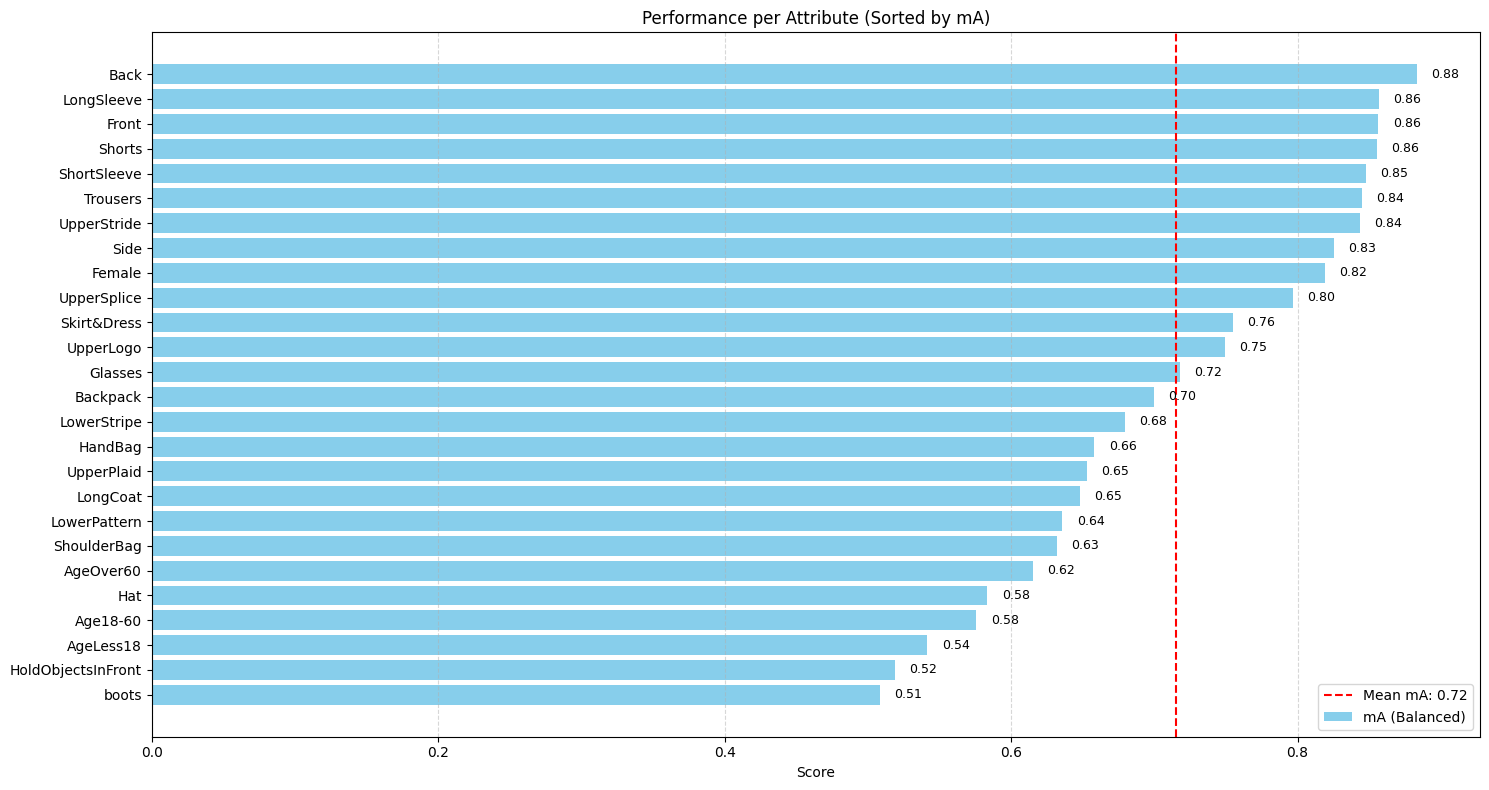


>>> 可视化推理样本 (Green=Correct, Red=Wrong)...


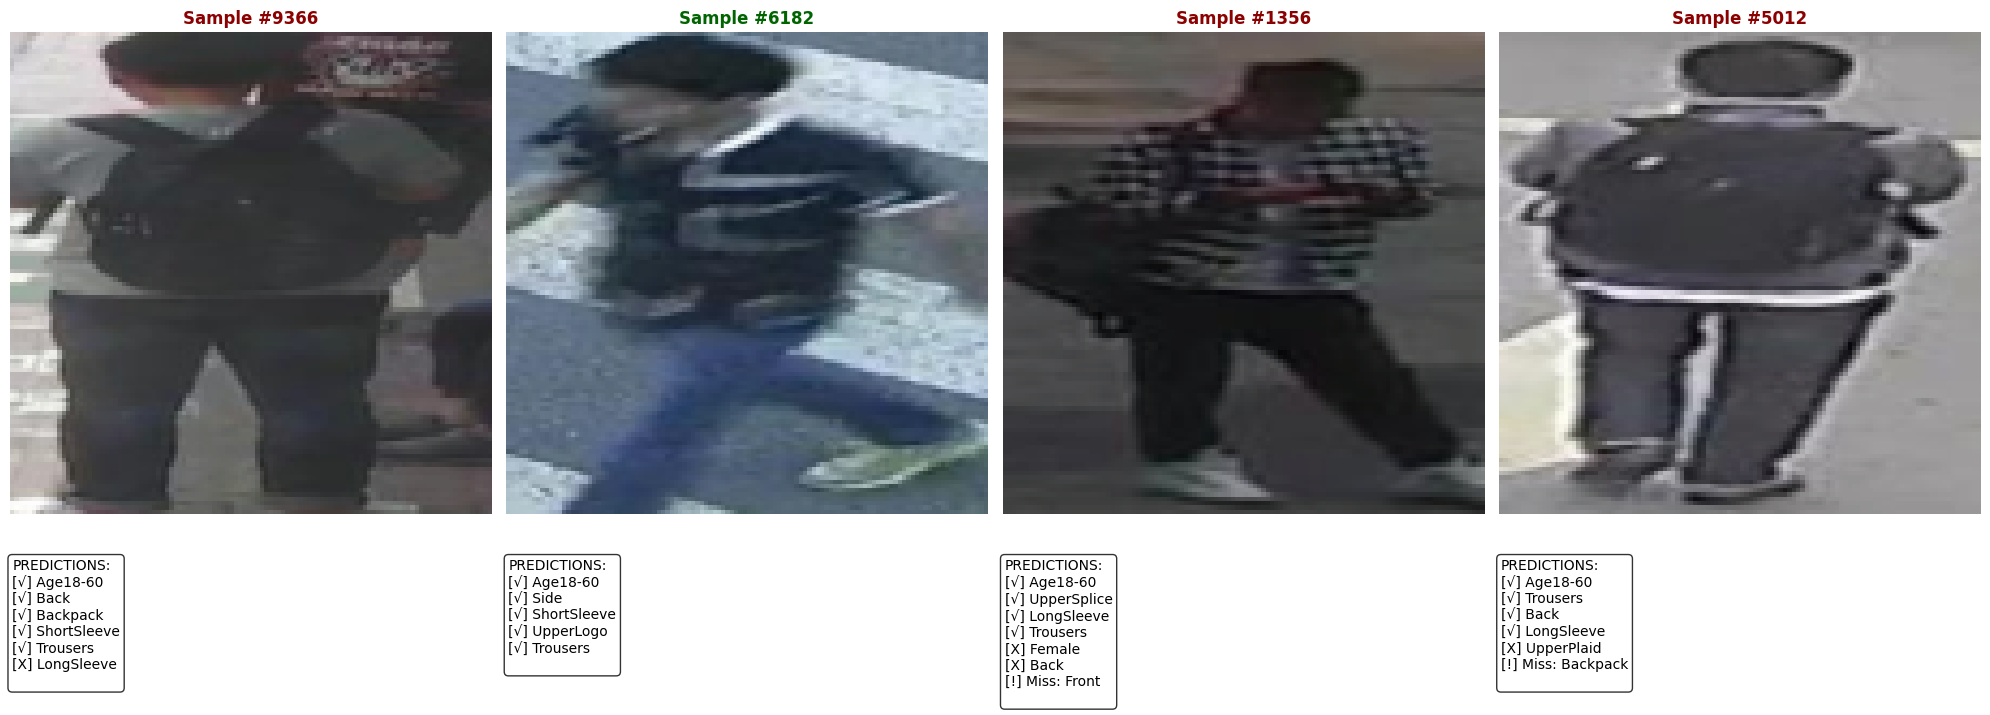

In [3]:
# --- 7. 模型评测与可视化 (新增 Cell) ---
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_and_visualize(model_path='best_model.pth'):
    print(">>> 正在加载最佳模型与测试数据...")
    
    # 1. 准备测试数据 (复用之前的 Dataset 类)
    # 注意：这里我们直接使用之前解析 mat 文件得到的 test_images 和 test_labels
    test_dataset = PA100KDataset(
        CONFIG['root_path'], 
        test_images, 
        test_labels, 
        transform=val_transform, # 测试时使用验证集的 Transform (只做 Resize 和 Normalize)
        cache_ram=False,         # 测试集可能较大，视内存情况可关闭缓存
        desc="Test"
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=CONFIG['batch_size'],
        shuffle=False,
        num_workers=CONFIG['num_workers'],
        pin_memory=True
    )

    # 2. 加载模型
    model = PedestrianAttributeNet(CONFIG['model_name'], CONFIG['num_classes']).to(CONFIG['device'])
    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=CONFIG['device']))
        print(f">>> 成功加载模型权重: {model_path}")
    else:
        print("!!! 未找到模型权重文件，请确保已训练并保存 best_model.pth")
        return

    model.eval()

    # 3. PA-100K 的 26 个属性名称 (按官方顺序)
    attributes = [
        'Female', 'AgeOver60', 'Age18-60', 'AgeLess18', 'Front', 'Side', 'Back', 
        'Hat', 'Glasses', 'HandBag', 'ShoulderBag', 'Backpack', 'HoldObjectsInFront', 
        'ShortSleeve', 'LongSleeve', 'UpperStride', 'UpperLogo', 'UpperPlaid', 'UpperSplice', 
        'LowerStripe', 'LowerPattern', 'LongCoat', 'Trousers', 'Shorts', 'Skirt&Dress', 'boots'
    ]

    # 4. 推理循环
    all_preds = []
    all_targets = []
    all_probs = []
    
    print(">>> 开始推理 (Inference)...")
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Testing"):
            images = images.to(CONFIG['device'])
            with torch.amp.autocast('cuda', enabled=CONFIG['use_amp']):
                logits = model(images)
                probs = torch.sigmoid(logits)
                preds = (probs > 0.5).int()
            
            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_targets.append(labels.numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    all_probs = np.concatenate(all_probs)

    # --- 5. 计算指标 ---
    # 计算每个属性的 mA (mean Accuracy)
    # mA = (Sensitivity + Specificity) / 2
    ma_per_attr = []
    acc_per_attr = []
    
    for i in range(CONFIG['num_classes']):
        # 获取第 i 个属性的预测和标签
        p = all_preds[:, i]
        t = all_targets[:, i]
        
        tp = np.sum((p == 1) & (t == 1))
        tn = np.sum((p == 0) & (t == 0))
        fp = np.sum((p == 1) & (t == 0))
        fn = np.sum((p == 0) & (t == 1))
        
        # 处理除零错误
        sens = tp / (tp + fn + 1e-6) # Recall (Positive)
        spec = tn / (tn + fp + 1e-6) # Recall (Negative)
        
        ma = (sens + spec) / 2
        acc = (tp + tn) / len(t)
        
        ma_per_attr.append(ma)
        acc_per_attr.append(acc)

    mean_mA = np.mean(ma_per_attr)
    print(f"\n>>> 最终测试集平均 mA: {mean_mA:.4f}")

    # --- 6. 可视化结果 ---
    
    # [图表 1]：各属性性能条形图
    plt.figure(figsize=(15, 8))
    # 创建 DataFrame 以便绘图
    df_metrics = pd.DataFrame({
        'Attribute': attributes,
        'mA': ma_per_attr,
        'Accuracy': acc_per_attr
    })
    # 按 mA 排序
    df_metrics = df_metrics.sort_values(by='mA', ascending=True)
    
    plt.barh(df_metrics['Attribute'], df_metrics['mA'], color='skyblue', label='mA (Balanced)')
    plt.axvline(mean_mA, color='red', linestyle='--', label=f'Mean mA: {mean_mA:.2f}')
    
    for index, value in enumerate(df_metrics['mA']):
        plt.text(value + 0.01, index, f"{value:.2f}", va='center', fontsize=9)

    plt.title('Performance per Attribute (Sorted by mA)')
    plt.xlabel('Score')
    plt.legend(loc='lower right')
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # [图表 2]：推理实例可视化 (Denormalize 用于显示图片)
    print("\n>>> 可视化推理样本 (Green=Correct, Red=Wrong)...")
    
    # 反归一化函数
    inv_normalize = T.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )

    # 随机抽取 4 张图片
    indices = np.random.choice(len(test_dataset), 4, replace=False)
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 8))
    
    for i, idx in enumerate(indices):
        # 获取原始数据
        img_tensor, label_tensor = test_dataset[idx]
        
        # 获取模型预测
        model_input = img_tensor.unsqueeze(0).to(CONFIG['device'])
        with torch.no_grad():
            output = torch.sigmoid(model(model_input)).squeeze().cpu().numpy()
        
        pred_indices = np.where(output > 0.5)[0]
        true_indices = np.where(label_tensor.numpy() == 1)[0]
        
        # 准备显示图片
        img_show = inv_normalize(img_tensor).permute(1, 2, 0).numpy()
        img_show = np.clip(img_show, 0, 1)
        
        axes[i].imshow(img_show)
        axes[i].axis('off')
        
        # 构建文本
        # 找出预测正确（TP）、漏检（FN）、误检（FP）
        pred_set = set(pred_indices)
        true_set = set(true_indices)
        
        correct = pred_set & true_set
        missed = true_set - pred_set
        wrong = pred_set - true_set
        
        text_str = "PREDICTIONS:\n"
        for attr_idx in correct:
            text_str += f"[√] {attributes[attr_idx]}\n" # 正确
        for attr_idx in wrong:
            text_str += f"[X] {attributes[attr_idx]}\n" # 误检
        for attr_idx in missed:
            text_str += f"[!] Miss: {attributes[attr_idx]}\n" # 漏检 (真实有，没预测出)
            
        if len(text_str) == 13: text_str += "(None)" # No attributes
            
        # 根据文本长度动态调整颜色
        color = 'black'
        if len(wrong) > 0 or len(missed) > 0:
            color = 'darkred' # 有错误
        else:
            color = 'darkgreen' # 全对
            
        axes[i].set_title(f"Sample #{idx}", color=color, fontweight='bold')
        # 在图片下方添加文本
        axes[i].text(0, CONFIG['img_size'] + 10, text_str, 
                     fontsize=10, verticalalignment='top', 
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()

# 执行评测
evaluate_and_visualize()

>>> 🚀 初始化终极评测模块...
>>> ✅ 模型权重已加载: best_model.pth

>>> ⏱️  正在进行速度基准测试 (Speed Benchmark)...
   [GPU] Latency (BS=1):  5.44 ms/img
   [GPU] Throughput (BS=32): 5880.5 FPS
   [CPU] Latency (BS=1):  7.74 ms/img
   [CPU] Throughput (BS=1):  129.2 FPS

>>> 🧠 正在进行全量推理 (Full Inference)...


Testing: 100%|██████████| 79/79 [00:06<00:00, 11.53it/s]



⭐️ Mean Accuracy (mA):  0.7154
⭐️ Instance Accuracy:   0.1329
⭐️ Hamming Loss:        0.0939

>>> [可视化 1] 属性详细得分表 (按 mA 降序)


,mA,Acc,Prec,Rec,F1
Back,88.32%,88.05%,75.87%,89.02%,81.92%
LongSleeve,85.66%,85.61%,88.61%,85.23%,86.89%
Front,85.64%,86.02%,72.69%,84.70%,78.24%
Shorts,85.55%,93.24%,73.04%,75.19%,74.10%
ShortSleeve,84.79%,84.21%,77.83%,89.72%,83.36%
Trousers,84.48%,90.51%,93.06%,95.01%,94.03%
UpperStride,84.34%,95.14%,59.74%,71.97%,65.29%
Side,82.56%,83.51%,80.26%,77.83%,79.03%
Female,81.90%,81.46%,72.71%,83.91%,77.91%
UpperSplice,79.68%,97.44%,77.52%,60.18%,67.76%


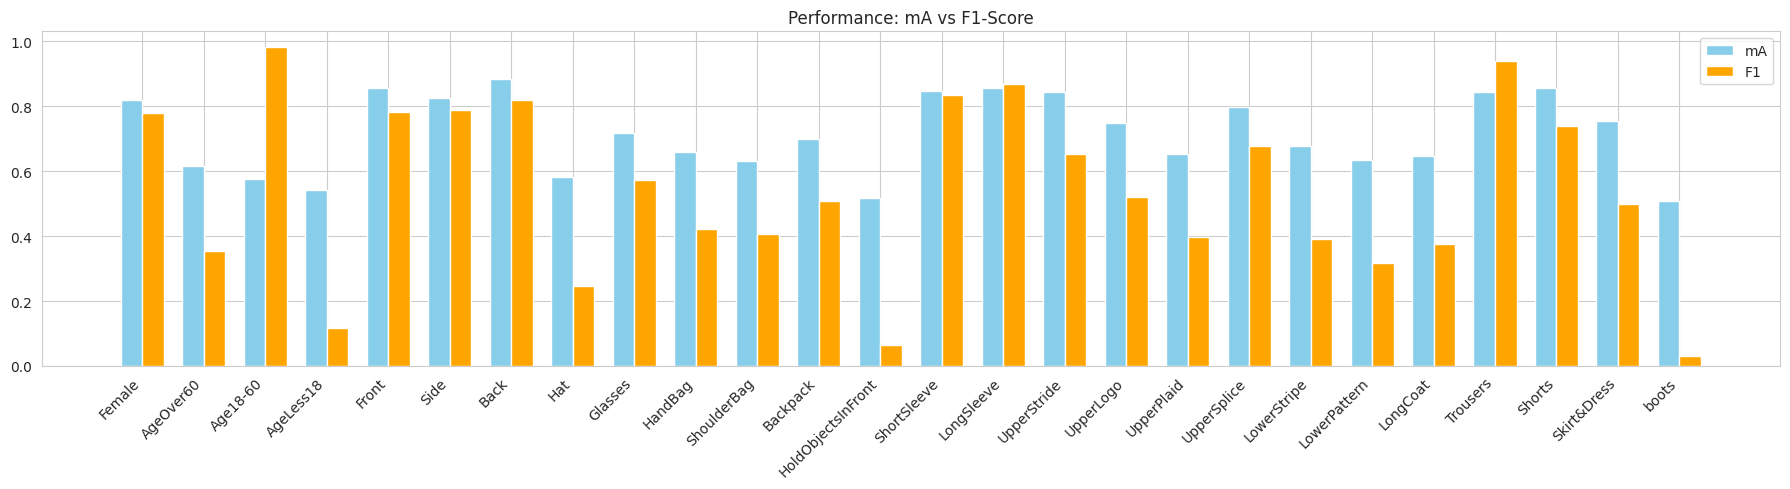

>>> [可视化 2] 预测结果相关性矩阵 (模型学到了什么关联?)


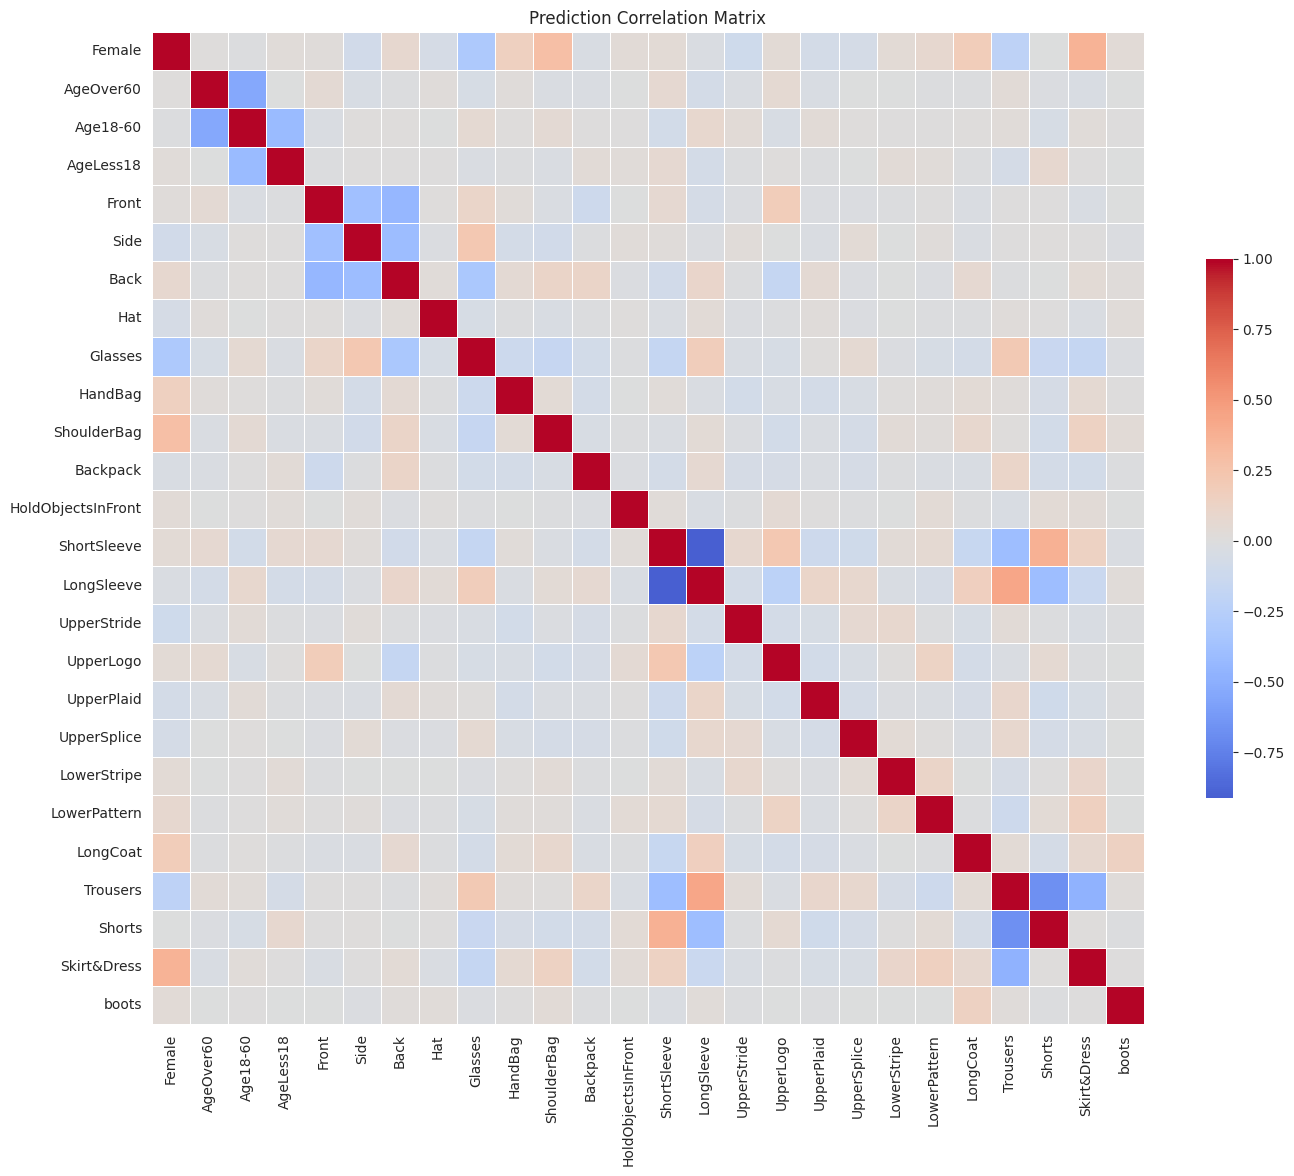


>>> ⛏️  困难样本挖掘 (Top 10 Hardest Samples)...


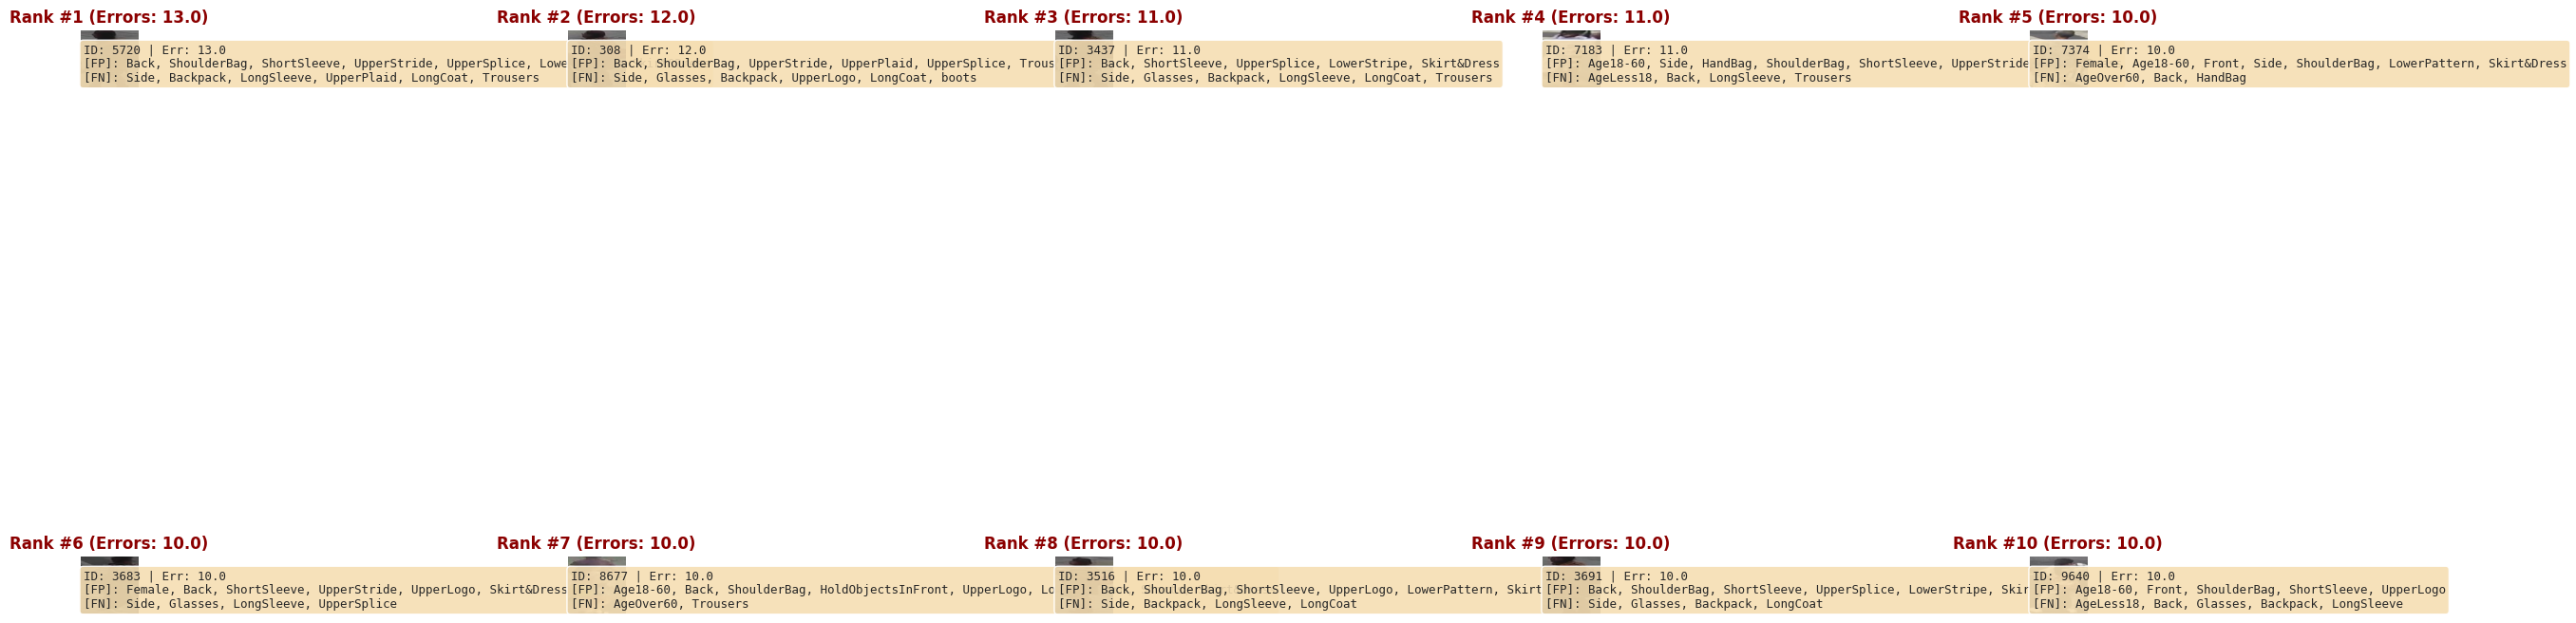


🖥️  HARDWARE ENVIRONMENT REPORT
CPU System:    Linux 6.6.105+
CPU Processor: x86_64
CPU Cores:     2 Physical / 4 Logical
GPU Device:    Tesla P100-PCIE-16GB
GPU Memory:    15.89 GB
CUDA Version:  12.4
CUDNN Version: 90300


In [8]:
# --- 8. 终极评测：全维度性能、效率分析与困难样本挖掘 ---
import time
import platform
import psutil
import pandas as pd
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, hamming_loss
import torch.backends.cudnn as cudnn

# -------------------------------------------------------------------------
# 工具函数：硬件与速度测试
# -------------------------------------------------------------------------
def get_hardware_info():
    info = "\n" + "="*60 + "\n"
    info += "🖥️  HARDWARE ENVIRONMENT REPORT\n"
    info += "="*60 + "\n"
    
    # CPU Info
    info += f"CPU System:    {platform.system()} {platform.release()}\n"
    info += f"CPU Processor: {platform.processor()}\n"
    info += f"CPU Cores:     {psutil.cpu_count(logical=False)} Physical / {psutil.cpu_count(logical=True)} Logical\n"
    
    # GPU Info
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
        gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
        info += f"GPU Device:    {gpu_name}\n"
        info += f"GPU Memory:    {gpu_mem:.2f} GB\n"
        info += f"CUDA Version:  {torch.version.cuda}\n"
        info += f"CUDNN Version: {torch.backends.cudnn.version()}\n"
    else:
        info += "GPU Device:    Not Available (Running on CPU)\n"
    
    info += "="*60
    return info

def benchmark_speed(model, input_shape, device, batch_size=1, warmup=10, reps=50):
    model = model.to(device)
    model.eval()
    dummy_input = torch.randn(batch_size, *input_shape).to(device)
    
    # Warmup
    with torch.no_grad():
        for _ in range(warmup):
            _ = model(dummy_input)
    
    # Timing
    timings = []
    with torch.no_grad():
        for _ in range(reps):
            if device.type == 'cuda': torch.cuda.synchronize()
            start = time.time()
            
            _ = model(dummy_input)
            
            if device.type == 'cuda': torch.cuda.synchronize()
            end = time.time()
            timings.append((end - start))
            
    avg_time = np.mean(timings)
    fps = batch_size / avg_time
    return avg_time * 1000, fps # ms, fps

# -------------------------------------------------------------------------
# 主评测逻辑
# -------------------------------------------------------------------------
def ultimate_evaluation(model_path='best_model.pth'):
    print(">>> 🚀 初始化终极评测模块...")
    
    # --- 1. 准备数据 ---
    # 使用 annotation.mat 中的测试集定义
    test_dataset = PA100KDataset(
        CONFIG['root_path'], 
        test_images, 
        test_labels, 
        transform=val_transform, 
        cache_ram=False, 
        desc="Test Data"
    )
    
    # --- 2. 加载模型 ---
    model = PedestrianAttributeNet(CONFIG['model_name'], CONFIG['num_classes'])
    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location='cpu')) # 先加载到 CPU
        print(f">>> ✅ 模型权重已加载: {model_path}")
    else:
        print("!!! ❌ 未找到权重文件，请检查。")
        return

    # --- 3. 速度与效率评测 (Benchmark) ---
    print("\n>>> ⏱️  正在进行速度基准测试 (Speed Benchmark)...")
    img_shape = (3, CONFIG['img_size'], CONFIG['img_size'])
    
    # GPU Benchmark
    if torch.cuda.is_available():
        latency_gpu, fps_gpu = benchmark_speed(model, img_shape, torch.device('cuda'), batch_size=1)
        _, fps_gpu_batch = benchmark_speed(model, img_shape, torch.device('cuda'), batch_size=32)
        print(f"   [GPU] Latency (BS=1):  {latency_gpu:.2f} ms/img")
        print(f"   [GPU] Throughput (BS=32): {fps_gpu_batch:.1f} FPS")
    
    # CPU Benchmark
    latency_cpu, fps_cpu = benchmark_speed(model, img_shape, torch.device('cpu'), batch_size=1)
    print(f"   [CPU] Latency (BS=1):  {latency_cpu:.2f} ms/img")
    print(f"   [CPU] Throughput (BS=1):  {fps_cpu:.1f} FPS")

    # --- 4. 精度评测 (Accuracy Evaluation) ---
    print("\n>>> 🧠 正在进行全量推理 (Full Inference)...")
    model = model.to(CONFIG['device'])
    test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, 
                             num_workers=CONFIG['num_workers'], pin_memory=True)
    
    all_probs, all_targets = [], []
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Testing"):
            images = images.to(CONFIG['device'])
            with torch.amp.autocast('cuda', enabled=CONFIG['use_amp']):
                logits = model(images)
                probs = torch.sigmoid(logits)
            all_probs.append(probs.cpu().numpy())
            all_targets.append(labels.numpy())

    y_score = np.concatenate(all_probs)
    y_true = np.concatenate(all_targets)
    y_pred = (y_score > 0.5).astype(int)
    
    attributes = [
        'Female', 'AgeOver60', 'Age18-60', 'AgeLess18', 'Front', 'Side', 'Back', 
        'Hat', 'Glasses', 'HandBag', 'ShoulderBag', 'Backpack', 'HoldObjectsInFront', 
        'ShortSleeve', 'LongSleeve', 'UpperStride', 'UpperLogo', 'UpperPlaid', 'UpperSplice', 
        'LowerStripe', 'LowerPattern', 'LongCoat', 'Trousers', 'Shorts', 'Skirt&Dress', 'boots'
    ]

    # --- 5. 计算指标 ---
    res_dict = {}
    metric_ma = []
    
    for i, attr in enumerate(attributes):
        p, t = y_pred[:, i], y_true[:, i]
        tp, tn = np.sum((p==1)&(t==1)), np.sum((p==0)&(t==0))
        fp, fn = np.sum((p==1)&(t==0)), np.sum((p==0)&(t==1))
        
        sens = tp / (tp + fn + 1e-6)
        spec = tn / (tn + fp + 1e-6)
        ma = (sens + spec) / 2
        metric_ma.append(ma)
        
        res_dict[attr] = {
            'mA': ma,
            'Acc': (tp+tn)/len(t),
            'Prec': precision_score(t, p, zero_division=0),
            'Rec': recall_score(t, p, zero_division=0),
            'F1': f1_score(t, p, zero_division=0)
        }
        
    df_metrics = pd.DataFrame.from_dict(res_dict, orient='index')
    mean_ma = np.mean(metric_ma)
    instance_acc = np.mean(np.all(y_pred == y_true, axis=1))
    h_loss = hamming_loss(y_true, y_pred)
    
    print(f"\n{'='*40}")
    print(f"⭐️ Mean Accuracy (mA):  {mean_ma:.4f}")
    print(f"⭐️ Instance Accuracy:   {instance_acc:.4f}")
    print(f"⭐️ Hamming Loss:        {h_loss:.4f}")
    print(f"{'='*40}\n")

    # --- 6. 可视化展示 ---
    sns.set_style("whitegrid")
    
    # [Table] 属性详细得分
    print(">>> [可视化 1] 属性详细得分表 (按 mA 降序)")
    df_sorted = df_metrics.sort_values(by='mA', ascending=False)
    try:
        display(df_sorted.style.background_gradient(cmap='RdYlGn', subset=['mA', 'F1'])\
                           .format("{:.2%}"))
    except:
        print(df_sorted)

    # [Plot 1] mA vs F1
    plt.figure(figsize=(18, 5))
    x = np.arange(len(attributes))
    width = 0.35
    df_plot = df_metrics.loc[attributes] # 按原始顺序
    plt.bar(x - width/2, df_plot['mA'], width, label='mA', color='skyblue')
    plt.bar(x + width/2, df_plot['F1'], width, label='F1', color='orange')
    plt.xticks(x, attributes, rotation=45, ha='right')
    plt.legend()
    plt.title('Performance: mA vs F1-Score')
    plt.tight_layout()
    plt.show()
    
    # [Plot 2] 预测相关性矩阵 (Model Logic Analysis)
    print(">>> [可视化 2] 预测结果相关性矩阵 (模型学到了什么关联?)")
    pred_df = pd.DataFrame(y_pred, columns=attributes)
    corr = pred_df.corr()
    plt.figure(figsize=(16, 14))
    sns.heatmap(corr, cmap='coolwarm', center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5})
    plt.title('Prediction Correlation Matrix')
    plt.show()

    # --- 7. 困难样本挖掘 (Hard Mining Top 10) ---
    print("\n>>> ⛏️  困难样本挖掘 (Top 10 Hardest Samples)...")
    errors_per_image = np.sum(np.abs(y_pred - y_true), axis=1)
    worst_indices = np.argsort(errors_per_image)[-10:] # Top 10
    
    inv_normalize = T.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    
    # 2行5列布局
    fig, axes = plt.subplots(2, 5, figsize=(24, 12))
    axes = axes.flatten()
    
    for i, idx in enumerate(reversed(worst_indices)): # 最错的在最前面
        img_tensor, _ = test_dataset[idx]
        img_show = inv_normalize(img_tensor).permute(1, 2, 0).numpy()
        img_show = np.clip(img_show, 0, 1)
        
        p_vec, t_vec = y_pred[idx], y_true[idx]
        fp = [attributes[k] for k in np.where((p_vec==1)&(t_vec==0))[0]] # 误检
        fn = [attributes[k] for k in np.where((p_vec==0)&(t_vec==1))[0]] # 漏检
        
        info = f"ID: {idx} | Err: {errors_per_image[idx]}\n"
        if fp: info += f"[FP]: {', '.join(fp)}\n"
        if fn: info += f"[FN]: {', '.join(fn)}"
        
        axes[i].imshow(img_show)
        axes[i].set_title(f"Rank #{i+1} (Errors: {errors_per_image[idx]})", color='darkred', fontweight='bold')
        axes[i].axis('off')
        
        # 文本框
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
        axes[i].text(0.05, 0.05, info, transform=axes[i].transAxes, fontsize=9,
                     verticalalignment='bottom', bbox=props, family='monospace')
        
    plt.tight_layout()
    plt.show()

    # --- 8. 硬件信息 ---
    print(get_hardware_info())

# 执行终极评测
ultimate_evaluation()